In [4]:
import pandas as pd

portfolio = pd.read_csv("C:\Data analyst projects\stock sales data 20222023\data\processed\product_portfolio_analysis.csv")

#sanity check
print(portfolio.shape)
print(portfolio.columns)
portfolio.head(10)

(8, 10)
Index(['item', 'total_sales', 'sales_share_pct', 'cumulative_share_pct',
       'ABC_class', 'avg_monthly_sales', 'std_monthly_sales', 'cv',
       'stability', 'segment'],
      dtype='object')


,item,total_sales,sales_share_pct,cumulative_share_pct,ABC_class,avg_monthly_sales,std_monthly_sales,cv,stability,segment
0,A,165520.0,28.647681,28.647681,A,7881.904762,7088.345307,0.899319,Moderate,A-Moderate
1,B,159961.0,27.685547,56.333228,A,7617.190476,7590.876442,0.996545,Moderate,A-Moderate
2,C,124175.0,21.491819,77.825047,A,5913.095238,5441.922977,0.920317,Moderate,A-Moderate
3,D,78987.0,13.670822,91.495869,B,3761.285714,3571.065529,0.949427,Moderate,B-Moderate
4,G,24347.0,4.213902,95.709771,C,1159.380952,1958.123093,1.688938,Volatile,C-Volatile
5,F,10253.0,1.774557,97.484328,C,488.238095,553.151327,1.132954,Volatile,C-Volatile
6,E,9509.0,1.645788,99.130116,C,452.809524,396.677403,0.876036,Moderate,C-Moderate
7,H,5026.0,0.869884,100.000000,C,239.333333,258.815249,1.081401,Volatile,C-Volatile


In [5]:
def assign_service_level(row):
    if row["ABC_class"]== "A":
        return 0.95 #95% service level
    elif row["ABC_class"]=="B":
        return 0.90 #90% service level
    else :
        return 0.85 #85%
portfolio["service_level"]= portfolio.apply(assign_service_level,axis=1)
portfolio[["item", "ABC_class", "service_level"]].sort_values(["ABC_class", "item"])

,item,ABC_class,service_level
0,A,A,0.95
1,B,A,0.95
2,C,A,0.95
3,D,B,0.90
6,E,C,0.85
5,F,C,0.85
4,G,C,0.85
7,H,C,0.85


In [7]:
z_map = {
    0.95 : 1.65,
    0.90 : 1.28,
    0.85 : 1.04
}

portfolio["z_value"]=portfolio["service_level"].map(z_map)
portfolio[["item","z_value","service_level"]]

,item,z_value,service_level
0,A,1.65,0.95
1,B,1.65,0.95
2,C,1.65,0.95
3,D,1.28,0.90
4,G,1.04,0.85
5,F,1.04,0.85
6,E,1.04,0.85
7,H,1.04,0.85


In [12]:
portfolio["safety_stock_units"]= portfolio["z_value"] * portfolio ["std_monthly_sales"]

portfolio[["safety_stock_units","item","z_value","service_level"]].sort_values("safety_stock_units", ascending = False)

,safety_stock_units,item,z_value,service_level
1,12524.946130,B,1.65,0.95
0,11695.769756,A,1.65,0.95
2,8979.172912,C,1.65,0.95
3,4570.963877,D,1.28,0.90
4,2036.448017,G,1.04,0.85
5,575.277380,F,1.04,0.85
6,412.544499,E,1.04,0.85
7,269.167859,H,1.04,0.85


In [16]:
portfolio["reorder_point_units"]= portfolio["avg_monthly_sales"]+portfolio["safety_stock_units"]

portfolio[["safety_stock_units","item","z_value","service_level", "reorder_point_units"]].sort_values("reorder_point_units", ascending = False)



,safety_stock_units,item,z_value,service_level,reorder_point_units
1,12524.946130,B,1.65,0.95,20142.136606
0,11695.769756,A,1.65,0.95,19577.674518
2,8979.172912,C,1.65,0.95,14892.268151
3,4570.963877,D,1.28,0.90,8332.249592
4,2036.448017,G,1.04,0.85,3195.828969
5,575.277380,F,1.04,0.85,1063.515475
6,412.544499,E,1.04,0.85,865.354023
7,269.167859,H,1.04,0.85,508.501193


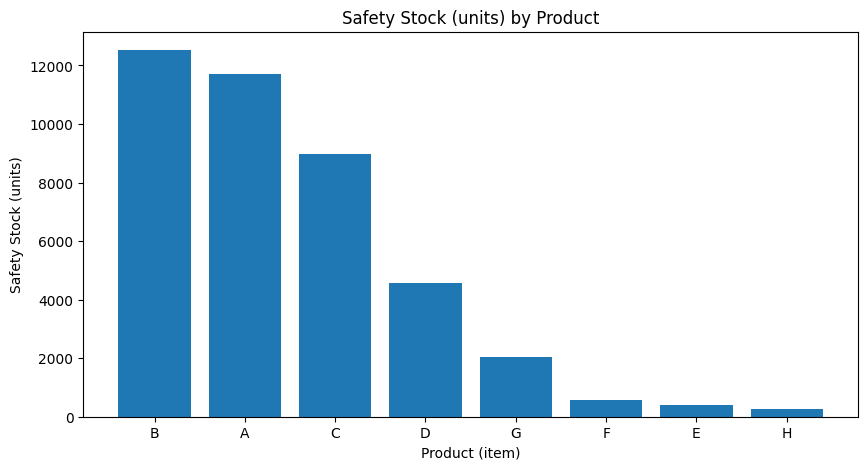

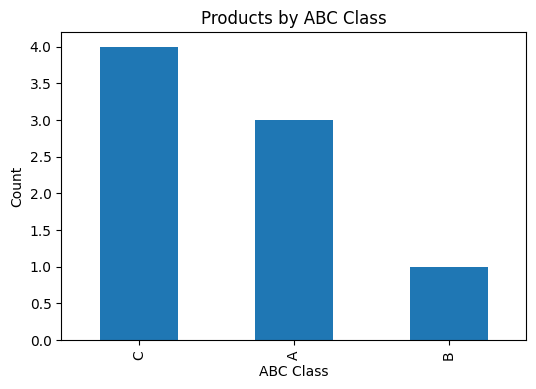

In [17]:
import matplotlib.pyplot as plt

# Safety stock by item
tmp = portfolio.sort_values("safety_stock_units", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(tmp["item"].astype(str), tmp["safety_stock_units"])
plt.title("Safety Stock (units) by Product")
plt.xlabel("Product (item)")
plt.ylabel("Safety Stock (units)")
plt.show()

# Service level by ABC class (count)
plt.figure(figsize=(6,4))
portfolio["ABC_class"].value_counts().plot(kind="bar")
plt.title("Products by ABC Class")
plt.xlabel("ABC Class")
plt.ylabel("Count")
plt.show()

In [ ]:
#A-items get higher service level because they drive most revenue (Umsatztreiber).

#Higher service level → higher Z-value → higher safety stock (Sicherheitsbestand).

#Volatile items naturally have higher σ, so they “cost more” to protect.

#C-items are managed lean to reduce overstock risk (Überbestand).

#This converts segmentation into an actionable replenishment rule (Nachschubregel).